In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
import os
import pydicom
import cv2
from tqdm import tqdm


DATA_DIR = "/kaggle/input/competitions/vinbigdata-chest-xray-abnormalities-detection/train"
OUTPUT_DIR = "/kaggle/working/converted_jpg"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Change this to 3000 (or more) as required
MAX_IMAGES = 3000

all_files = [f for f in os.listdir(DATA_DIR) if f.lower().endswith(".dicom")]
files = all_files[:MAX_IMAGES]

print("Total DICOM files found:", len(all_files))
print("Converting only:", len(files), "files")

count = 0

for fname in tqdm(files):
    dcm_path = os.path.join(DATA_DIR, fname)
    try:
        ds = pydicom.dcmread(dcm_path)
        img = ds.pixel_array

        # Normalize to 0-255 and convert to uint8
        img = (img / img.max() * 255).astype("uint8")

        # Optional: resize to save space (uncomment if needed)
        # img = cv2.resize(img, (512, 512))

        jpg_name = fname.replace(".dicom", ".jpg")
        jpg_path = os.path.join(OUTPUT_DIR, jpg_name)

        # Save as JPG (much smaller than PNG)
        cv2.imwrite(jpg_path, img, [int(cv2.IMWRITE_JPEG_QUALITY), 90])

        count += 1
    except Exception as e:
        print("Error processing:", fname, e)

print("✅ Conversion completed.")
print("✅ Total images converted:", count)


Total DICOM files found: 15000
Converting only: 3000 files


100%|██████████| 3000/3000 [53:23<00:00,  1.07s/it]  

✅ Conversion completed.
✅ Total images converted: 3000


In [4]:
import os
import cv2
import numpy as np
from tqdm import tqdm

INPUT_DIR = "/kaggle/working/converted_jpg"
OUTPUT_DIR = "/kaggle/working/preprocessed_jpg"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# List JPG files
files = [f for f in os.listdir(INPUT_DIR) if f.lower().endswith(".jpg")]
print("Total images found for preprocessing:", len(files))

count = 0

for fname in tqdm(files):
    img_path = os.path.join(INPUT_DIR, fname)

    # Read image in grayscale
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print("Could not read image:", fname)
        continue

    # Resize to 224x224
    img_resized = cv2.resize(img, (224, 224))

    # Normalize to 0-1
    img_normalized = img_resized / 255.0

    img_to_save = (img_normalized * 255).astype(np.uint8)

    # Save preprocessed image
    save_path = os.path.join(OUTPUT_DIR, fname)
    cv2.imwrite(save_path, img_to_save)

    count += 1

print("✅ Preprocessing completed.")
print("✅ Total images preprocessed:", count)


Total images found for preprocessing: 3000


100%|██████████| 3000/3000 [01:27<00:00, 34.30it/s]

✅ Preprocessing completed.
✅ Total images preprocessed: 3000


Number of preprocessed images: 3000
Showing preprocessed image: d22e6aec7d43fed24900e1c34161637d.jpg


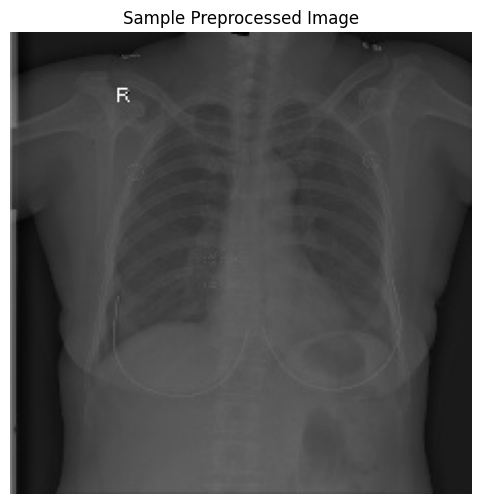

In [6]:
import os
import matplotlib.pyplot as plt
from PIL import Image

pre_dir = "/kaggle/working/preprocessed_jpg"

files = [f for f in os.listdir(pre_dir) if f.lower().endswith(".jpg")]
print("Number of preprocessed images:", len(files))

sample_file = files[0]
print("Showing preprocessed image:", sample_file)

img_path = os.path.join(pre_dir, sample_file)
img = Image.open(img_path)

plt.figure(figsize=(6, 6))
plt.imshow(img, cmap="gray")
plt.title("Sample Preprocessed Image")
plt.axis("off")
plt.show()